In [20]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings

using Revise
using SkyrmionTunneling
const ST = SkyrmionTunneling # alias

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`


SkyrmionTunneling

In [4]:
PeriodicBoundary()

PeriodicBoundary()

In [5]:
ST.print_test()

Hello!


In [6]:
ST.print_test_4()

Update read automatically, 4, meeee!!


In [7]:
ST.test_energy()

correct FM energy ------> OK
err = 7.105427357601002e-15
S_z invariance ------> test passed


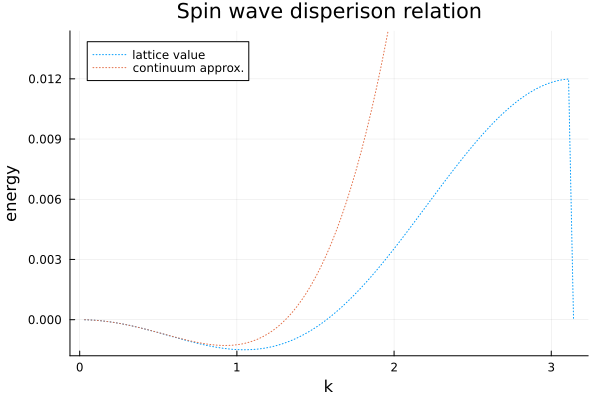

The preferred wavevector is k0 = 1.04, corresponding to the period L0 = 6.06
The continuum length scale is sqrt(I2/I1) = 0.7637626158259734


In [10]:
function plane_wave(nx,ny,k;amp=0.001)
    X = repeat(collect(1.0:nx)', ny, 1)
    Y = repeat(collect(1.0:ny), 1, nx)
    theta = amp*sin.(k .*X)
    n = zeros(3,nx,ny)
    n[1,:,:] = sin.(theta)
    n[3,:,:] = cos.(theta)
    return n
end

let
    nx = 200; ny = 200
    J1 = 1.0; J2 = -0.35; J3 = 1/16*(-J1+4*J2); K = 0.0
    B = ST.uniform_B(nx,ny,0.0)
    boundary = PeriodicBoundary()

    I1 = -2*(J1+2*J2+4*J3)
    I2 = -1/8*(J1+4*J2+16*J3)

    A = 1e-3 #small amplitude ---> linear
    k_vals = [2pi/nx * p for p=1:div(nx,2)]

    H_vals = [ST.H_vect(plane_wave(nx,ny,k,amp=A), J1, J2, J3, K, B, boundary) for k in k_vals]
    H_continuum = [A^2/8*(nx*ny) * (-I1*k^2 + I2*k^4) for k in k_vals]

    P = ST.plot(k_vals, H_vals, xlabel="k", ylabel="energy", ls=:dot, label="lattice value",title="Spin wave disperison relation", 
                ylims=(minimum(H_vals)*1.2, maximum(H_vals)*1.2))
    ST.plot!(P,k_vals, H_continuum, xlabel="k", ylabel="energy", ls=:dot, label="continuum approx.")
    display(P)

    k0 = k_vals[argmin(H_vals)]
    L0 = 2pi/k0
    println("The preferred wavevector is k0 = ", round(k0,digits=2), ", corresponding to the period L0 = ", round(L0,digits=2))
    println("The continuum length scale is sqrt(I2/I1) = ", sqrt(I2/I1))
end


### Relaxation dynamics

To minimize the energy, we would like to perform gradient descent on $n$ :
$$
\dot{n} = - \nabla_n H
$$
But this would be unphysical as we need to ensure $|n|=1$. To fix the issue, we simply subtract from the RHS the part proportional to $n$, obtaining
$$
\dot{n} = -\nabla_n H + (n \cdot \nabla_n H) \; n
$$
so that $n \dot{n} = 0$.

Maybe a ($n^2=1$ constrained) variant of Newton's method could be used? The Hessian is easy enough to compute, since $H$ is quadratic in $n$.

Progress: 100%|█████████████████████████████████████████| Time: 0:00:06


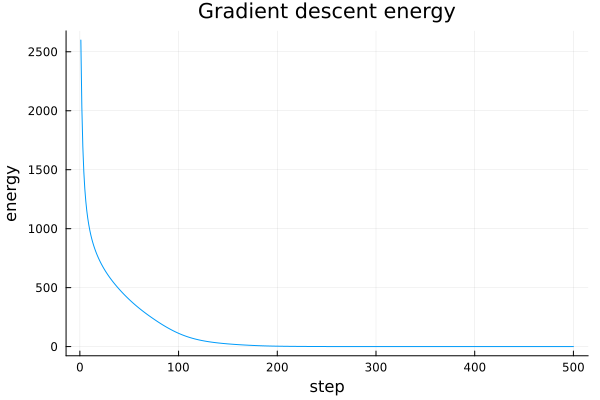

LoadError: UndefVarError: `n_final` not defined in `SkyrmionTunneling`
Suggestion: check for spelling errors or missing imports.

In [12]:
nx = 50; ny = 50
J1 = 1.12; J2 = -0.521; J3 = 1/16*(-J1+4*J2)+0.23; K = 0.007
B = ST.uniform_B(nx,ny,0.12)
boundary = FreeBoundary()
n_init = ST.random_configuration(nx,ny)

dt = 0.1;
N_steps = 500
boundary = PeriodicBoundary()
n_final = ST.relax(n_init,nx,ny,J1,J2,J3,K,B,dt,N_steps,boundary,graph=true)
print("reached ferromagnetic : ", ST.is_ferro(n_final,threshold=0.15))

## Skyrmions

In [14]:
function skyrmion_ansatz(nx, ny, R_0)
    """
    generates a config with Q=1 via a stereographic projection of id: S^2 -> S^2;
    b is the size of the 'skyrmion'
    """
    X = repeat(collect(1.0:nx)', ny, 1)
    Y = repeat(collect(1.0:ny), 1, nx)

    # shift the centre
    X .-= div( nx, 2 ) + 0.5
    Y .-= div( nx, 2 ) + 0.5

    R = sqrt.(X.^2 .+ Y.^2)
    l0 = 2.0
    theta = π .- 2 .* atan.(R .* exp.((R .- R_0) ./ l0))

    # compute the projection
    n = zeros(Float64, 3, nx, ny)
    n[1, :, :] .= sin.(theta) .* X ./ R
    n[2, :, :] .= sin.(theta) .* Y ./ R
    n[3, :, :] .= cos.(theta)
    return n
end

skyrmion_ansatz (generic function with 1 method)

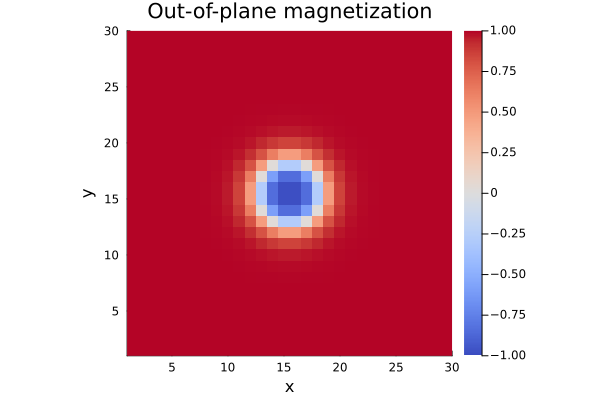

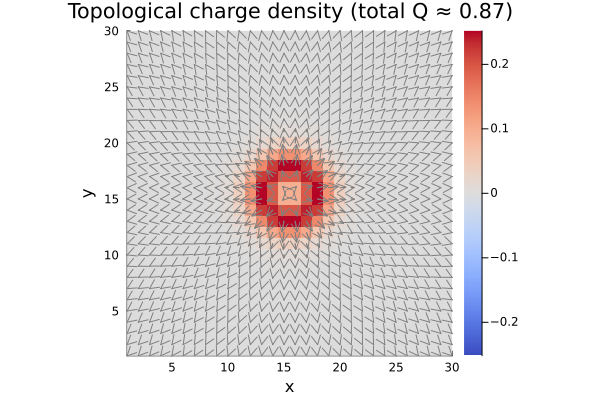

In [18]:
nx = 30; ny = 30; R_0 = 5.0
n = skyrmion_ansatz(nx,ny,R_0)
ST.show_skyrmion(n)

In [21]:
function mean_field_skyrmion(nx,ny,J1,J2,J3,K,B;b=1.7,show=true)
    I1 = -2*(J1+J2+4*J3) ### this is missing a factor of 2 in front of J2
    I2 = -1/8*(J1+4*J2+16*J3)
    I3 = 1/24*(J1-4*J2+16*J3)
    x0 = sqrt(I2/I1)
    Ha = I2 / I1^2 * B[div(nx,2), div(ny,2)]
    q = sqrt(-1 + sqrt(1-4*Ha + 0im) +0im)

    # dimensionfull coordinates
    X = repeat(collect(1.0:nx)', ny, 1)
    Y = repeat(collect(1.0:ny), 1, nx)

    # shift the centre
    X .-= div( nx, 2 ) + 0.5
    Y .-= div( nx, 2 ) + 0.5

    R = sqrt.(X.^2 .+ Y.^2) #dimensionfull length
    theta = pi*exp.(-real(q) * (R/x0) /b) .* cos.( imag(q)*(R/x0) /b)

    # compute the spin components
    n = zeros(Float64, 3, nx, ny)
    n[1, :, :] .= sin.(theta) .* X ./ R
    n[2, :, :] .= sin.(theta) .* Y ./ R
    n[3, :, :] .= cos.(theta)
    
    if show
        println("J1 = ", J1, ",\tJ2 = ", J2, "\tJ3 = ", J3, "\n K = ",K,"\tB_middle = ",B[div(nx,2), div(ny,2)],"\n")
        println("I1 = ", round(I1,digits=2),"\nI2 = ", round(I2,digits=2))
        println("spatial anisotropy ratio : ", round(I3/I2,digits=2))
        x0 = sqrt(I2/I1)
        println("sqrt(I2/I1) length scale = ", round(x0,digits=2))
        println("H_MF = ",round(I2/I1^2,digits=2), "*H_micro = ", round(Ha,digits=2))
        if Ha<1/4
            println("\n\nHa < 1/4 -----> SKYRMIONS MIGHT BE UNSTABLE")
        end
        println("\nContinuum approximation guess suggests")
        r = LinRange(0,30,100) #non-dimensional length
        theta = exp.(-real(q) * r/b) .* cos.( imag(q)*r/b)
        P = plot(r,theta, label="Ha = "*string(round(Ha,digits=2)),xlabel="r non-dim",ylabel=L"\theta", title=L"\theta\;\; \textrm{ profile}")
        display(P)

        println("\nfor which the skyrmion looks as follows")
        show_skyrmion(n)
    end


    return n
end

mean_field_skyrmion (generic function with 1 method)